## Example 4:  Non-Markovian RNA splicing model

The DynGPT package can be applied to solve a given non-Markovian state transition network and infer the associated model parameters. In this section, we will demonstrate the basic use of DynGPT using the Non-Markovian RNA splicing model as an illustrative example.

<img src="../../_static/image/Figure5.jpg" alt="Schematic of the Non-Markovian RNA splicing model" width="400" height="150" style="display: block; margin: auto;">

The STN of non-Markovian RNA splicing model can be described as: <br>
(1)	The system state is $s={{\left({{s}_{\text{OFF}}},{{s}_{\text{ON}}},{{s}_{\text{nRNA}}},{{s}_{\text{mRNA}}}\right)}^{\text{T}}}\in {{\left\{ 0,1 \right\}}^{2}}\times{{\mathbb{N}}^{2}},$ where ${{s}_{\text{OFF}}}$ and ${{s}_{\text{ON}}}$ indicate whether the promoter is in the inactive or active state, ${{s}_{\text{nRNA}}}$ and ${{s}_{\text{mRNA}}}$ are the number of nascent RNA and mature RNA molecules, respectively. <br>
(2)	Event sets are $\mathcal{R}=\left\{ \left. {{\mathcal{R}}_{1}},\ldots ,{{\mathcal{R}}_{5}} \right\} \right.,$ where ${{\mathcal{R}}_{1}}$ represents promoter binding, ${{\mathcal{R}}_{2}}$ represents promoter unbinding, ${{\mathcal{R}}_{3}}$ represents transcription of nascent RNA, ${{\mathcal{R}}_{4}}$ represents splicing of nascent RNA into mature mRNA , ${{\mathcal{R}}_{5}}$ represents degradation of mature RNA. <br>
(3)	State change vectors are: $\left\{{{\Delta }^{\left(k\right)}} \right\},k=1,2,\ldots ,5,$ where ${{\Delta }^{\left(k \right)}}=\left(\Delta_{\text{OFF}}^{\left(k\right)},\Delta_{\text{ON}}^{\left( k \right)},\Delta_{\text{nRNA}}^{\left(k\right)},\Delta_{\text{mRNA}}^{\left(k\right)} \right)$ represents the state change vector corresponding to $k\text{-th}$ event with 
$$\begin{align}
  & \Delta _{i}^{\left( 1 \right)}=-{{\delta }_{i,\text{OFF}}}+{{\delta }_{i,\text{ON}}}, \\ 
 & \Delta _{i}^{\left( 2 \right)}={{\delta }_{i,\text{OFF}}}-{{\delta }_{i,\text{ON}}}, \\ 
 & \Delta _{i}^{\left( 3 \right)}={{\delta }_{i,\text{nRNA}}}, \\ 
 & \Delta _{i}^{\left( 4 \right)}=-{{\delta }_{i,\text{nRNA}}}+{{\delta }_{i,\text{mRNA}}}, \\ 
 & \Delta _{i}^{\left( 5 \right)}=-{{\delta }_{i,\text{mRNA}}}, \\ 
\end{align}$$
where $i\in \left\{ \text{OFF},\text{ON},\text{nRNA},\text{mRNA} \right\}$ and ${{\delta }_{i,j}}$ is the Kronecker delta. <br>
(4) The propensity functions of events are: ${{\lambda }_{1}}={{k}_{\text{on}}}{{s}_{\text{OFF}}}$, ${{\lambda }_{2}}={{k}_{\text{off}}}{{s}_{\text{ON}}}$, ${{\lambda }_{3}}={{k}_{\text{syn}}}{{s}_{\text{ON}}}$, ${{\lambda }_{4}}={{k}_{\text{spl}}}{{s}_{\text{nRNA}}}$ and ${{\lambda }_{5}}={{k}_{\deg }}{{s}_{\text{mRNA}}}$. <br>

We consider that the following four events involve delays introduced by molecular memory and change the state only upon events’ completion (delays finish): promoter state transitions (activation and inactivation), splicing of nascent mRNAs, and degradation of mature mRNAs. That is, $\mathcal{R}{{}_{k}}\in \mathcal{R}{{}^{\left( \text{CD} \right)}}$ with $k=1,2,4,5$ and $\mathcal{R}{{}_{3}}\in \mathcal{R}{{}^{\left( \text{ND} \right)}}.$ We denote the corresponding delays follow Gamma distributions, represented as ${{f}_{\text{on}}}\left( {{k}_{\text{on}}},{{r}_{\text{on}}} \right),\text{ }{{f}_{\text{off}}}\left( {{k}_{\text{off}}},{{r}_{\text{off}}} \right),\text{ }{{f}_{\text{spl}}}\left( {{k}_{\text{spl}}},{{r}_{\text{spl}}} \right)$ and ${{f}_{\text{deg}}}\left( {{k}_{\text{deg}}},{{r}_{\text{deg}}} \right),$ respectively. Note that Gamma distributions can characterize multi-step behaviors introduced by molecular memory. In this STN, the input of the DynGPT-Solver is the parameters ${{\theta }_{\text{dyn}}}=\left\{ {{k}_{\text{on}}},{{r}_{\text{on}}},{{k}_{\text{off}}},{{r}_{\text{off}}},{{k}_{\text{syn}}},{{k}_{\text{spl}}},{{r}_{\text{spl}}},{{k}_{\deg }},{{r}_{\deg }} \right\}.$


### 1. Generate configuration file

To facilitate data generation and subsequent neural network training, we need create a configuration file for theNon-Markovian RNA splicing model that encapsulates its key properties. The key propertie of STN primarily consists of the following components:<br>
(1) State-related configuration: This includes the names of the states. In Non-Markovian RNA splicing model, the state names (`state_names`) are: ("ON", "OFF", "nRNA", "mRNA"). <br>
(2) Event-related configuration: The occurrence rate functions governing event dynamics, and state transition vectors associated with each event's occurrence. In Non-Markovian RNA splicing model, the state transition vectors (`state_transition`) are: ${{\lambda }_{1}}={{k}_{\text{on}}}{{s}_{\text{OFF}}}$, ${{\lambda }_{2}}={{k}_{\text{off}}}{{s}_{\text{ON}}}$,${{\lambda }_{3}}={{k}_{\text{syn}}}{{s}_{\text{ON}}}$,${{\lambda }_{4}}={{k}_{\text{spl}}}{{s}_{\text{nRNA}}}$ and ${{\lambda }_{5}}={{k}_{\deg }}{{s}_{\text{mRNA}}}$. Specifically, in certain events, specific states actively participate and drive the occurrence of the event without changing their own state. Such a state is referred to as an `drive state` in the context of the event. In ${{R}_{3}}$,ON can be described as active state, as its presence is essential for initiating the mRNA transciption while remaining unchanged in the event . <br>
(3) Parameter-related configuration: The name of parameter values and the range of parameters. In Non-Markovian RNA splicing model,the parameter names (`param_names`) are: ["kon", "ron","koff","roff", "ksyn", "kspl", "rspl", "kdeg", "rdeg"]. Upper bound value of parameters (`upper_bound_val`): [5, 5, 5, 5, 30, 5, 5, 5, 5]. Lower bound value of parameters (`lower_bound_val`): [0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01].<br>
 &nbsp;&nbsp; &nbsp;&nbsp;Additionally, we need to specify several hyperparameters for performing SSA simulations on the STN, including the model name (`model_name`), the initial values (`initial_val`), the maximum simulation time (`t_end`), the number of parameter sets to simulate for the training (`train_data_size`) and validation datasets (`valid_data_size`), and the directory for storing the resulting simulation data (`dataset_dir`). Specifically, in the Non-Markovian RNA splicing model, ON and OFF are mutually exclusive, such that their sum is always equal to 1. Consequently, it suffices to record the state value of ON, mRNA, and Protein. Accordingly, we define a subset of state indices corresponding to the state names to extract, referred to as the `minimal_state_indices`.

Hence, the following configuration files can be defined for Non-Markovian RNA splicing model. And we use Python's json package to store this configuration for subsequent simulation and neural network training.

In [ ]:
config_file = {
    "state_names": ["ON", "OFF", "nRNA", "mRNA"],
    "events": [
        {"state_transition": {"OFF": -1, "ON": 1}, "event_rates": "kon*OFF"},
        {"state_transition": {"ON": -1, "OFF": 1}, "event_rates": "koff*ON"},
        {"state_transition": {"nRNA": 1}, "event_rates": "ksynon*ON", "drive_state": "ON"},
        {"state_transition": {"nRNA": -1, "mRNA": 1}, "event_rates": "kspl*nRNA"},
        {"state_transition": {"mRNA": -1}, "event_rates": "kdeg*mRNA"},
    ],
    "parameters": {
        "param_names": ["kon", "ron", "koff", "roff", "ksyn", "kspl", "rspl", "kdeg", "rdeg"],
        "upper_bound_val": [5, 5, 5, 5, 30, 5, 5, 5, 5],
        "lower_bound_val": [0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01],
    },
    "model_name": "NM_RNA_splice",
    "initial_val": [1, 0, 0, 0],
    "t_end": 6000,
    "train_data_size": 10000,
    "valid_data_size": 1000,
    "dataset_dir": "/GPUFS/sysu_jjzhang_1/hzw/academicCode/DynGPTTest/DynGPT/data/NM_RNA_splice/",
    "minimal_state_indices": [1, 3, 4],
    "state_upper_bound": [2, 251, 250],
    "observed_data_indices": [3, 4]
}
with open("config/{}_config.json".format(config_file["model_name"]), "w") as file:
    json.dump(config_file, file, indent=4)

### 2. Generate datasets

After generating the configuration file, we construct and simulate a state transition network for the gene expression central dogma model to obtain the dataset required for training the neural network addressing the model. The simulation is implemented in Julia, which provides higher efficiency for stochastic simulation algorithms (SSA) compared to Python. To generate the training data, execute the following command in the terminal:

In [ ]:
julia nm_simulation.jl /path/to/config.json

### 3. Train DynGPT-Solver

In [1]:
# import packages
import sys
import os
import numpy as np
import json
import logging
import warnings
root_dir = "/GPUFS/sysu_jjzhang_1/hzw/academicCode/DynGPTTest/DynGPT/"
sys.path.append(root_dir)
os.chdir(root_dir)
import dyngpt as dg
logging.getLogger().setLevel(logging.ERROR)
warnings.filterwarnings("ignore")

To train a neural network for addressing the Non-Markovian RNA splicing model and inferring its parameters, a basic configuration file must first be defined. This file includes four key components: (1) the information of the Non-Markovian RNA splicing model, (2) the neural network architecture, (3) the directory for saving outputs and visualizations, and (4) the default parameter settings for the neural network. Subsequent configurations for training, sampling, and inference build upon this foundation by incorporating additional task-specific parameters as needed. The relationships between the configurations of each subsequent stage are presented as follows:

<img src="../../_static/image/Figure_config.jpg" alt="Schematic of config" width="600" height="200">

Firstly, the basic configuration file must include detailed information about the underlying dynamic model.

In [2]:
config_basic = {}
config_path_dynmodel = "your_path_config"
model_name ="NM_RNA_splice"
config_path_dynmodel = "config/{}_config.json".format(model_name)
with open(config_path_dynmodel, 'r') as file:
    dynmodel_config = json.load(file)
config_basic = dg.tl.update_dynmodel_config(config_basic,config_path_dynmodel)

Next, the architecture of the neural network is defined by specifying the relevant structural details within the configuration.

In [3]:
config_basic["num_encoder_layers"] = 1  # transformer n_layer
config_basic["n_head"] = 8  # transformer n_head
config_basic["feed_forward_dimension"] = 1024  # transformer feed_forward_dimension

Additionally, the user must designate a directory for saving output files and visualizations.

In [4]:
config_basic["dataset_dir"]="your/path/to/saveresult/"
config_basic["figure_dir"]="your/path/to/savefigure/"
config_basic["result_dir"]="result/{}/".format(config_basic["model"])
config_basic["figure_dir"]="figure/{}/".format(config_basic["model"])

Finally, execute the provided code to append default configuration parameters.

In [5]:
config_basic = dg.tl.update_default_config(config_basic)

After defining the configuration file, we proceed to train the neural network designed to solve the Non-Markovian RNA splicing model. The training process is divided into two stages: the first stage involves pretraining the neural network, while the second stage focuses on fine-tuning it. Additionally, for each stage, we will visualize the corresponding loss function curves to evaluate the training progress.

For model pretraining, the configuration file is extended from the basic configuration. The user should specify the number of epochs (`epochs_pretrain`) and the training dataset path (`train_dataset_path`) in the configuration file.

In [ ]:
config_pretrain = config_basic
config_pretrain.epochs_pretrain = 1000
config_pretrain.train_dataset_path = "your/path/to/train_dataset"
result_pre_train = dg.solver.pre_training(config_pretrain)

Visualize the loss values during the pretraining phase of the model.

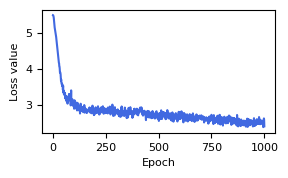

In [6]:
result_pre_train = np.load("result/NM_RNA_splice/train_loss/NM_RNA_splice_epoch1000.npz")
dg.pl.plot_loss(result_pre_train["loss_mean"])

During the fine-tuning phase, the configuration file is also extended from the basic configuration, specifying the number of epochs (`epochs_fine_tune`), the training dataset path (`train_dataset_path`), and the pretrained network weights (`weight_nn_pretrain_path`).

In [ ]:
config_fine_tune = config_basic
config_fine_tune.epochs_fine_tune = 1000
config_pretrain.train_dataset_path = "your/path/to/train_dataset"
config_fine_tune.weight_nn_pretrain_path = result_pre_train["weight_nn_pretrain_path"]
result_fine_tune = dg.solver.fine_tune_training(config_fine_tune)

Visualize the loss values during the fine tunning phase of the model.

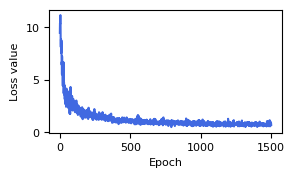

In [8]:
result_fine_tune = np.load("result/NM_RNA_splice/train_loss/fine_tune_NM_RNA_splice_epoch1500.npz")
dg.pl.plot_loss(result_fine_tune["loss_mean"])

After the neural network training converges, we valid the performance of the neural network model in solving Non-Markovian RNA splicing model from comparative analysis of the samples generated by the neural network and those obtained through simulations in terms of their mean, standard deviation, and overall distribution. 
When using the trained model for sampling, the configuration file is also extended from the basic configuration, specifying the validation dataset path (`valid_dataset_path`) and incorporating the fine-tuned network weights (`weight_nn_fine_tune_path`).

In [19]:
config_sampling = config_basic
# valid_dataset_path =  "your/valid/datasetpath/"
valid_dataset_path =  "data/nm_nm/nm_nm_valid_stable.json"
# config_sampling.weight_nn_fine_tune_path = result_fine_tune["weight_nn_fine_tune_path"]
config_sampling.weight_nn_fine_tune_path = "/GPUFS/sysu_jjzhang_1/hzw/academicCode/DynGPTTest/DynGPT/dyngpt/_weights/nm_nm_final.pt"
config_sampling.weight_nn_fine_tune_path = "/GPUFS/sysu_jjzhang_1/hzw/academicCode/DynGPTTest/DynGPT/dyngpt/_weights/nm_nm_epoch11000.pt"
config_sampling.valid_dataset_path = valid_dataset_path
result_valid_set = dg.tl.compute_sampling_stats(config_sampling,param_index = range(200))

the indices length is 300


We visualize the performance of the neural network model on the validation set. This includes a comparative analysis of the samples generated by the neural network and those obtained through simulations in terms of their mean, standard deviation, and overall distribution.

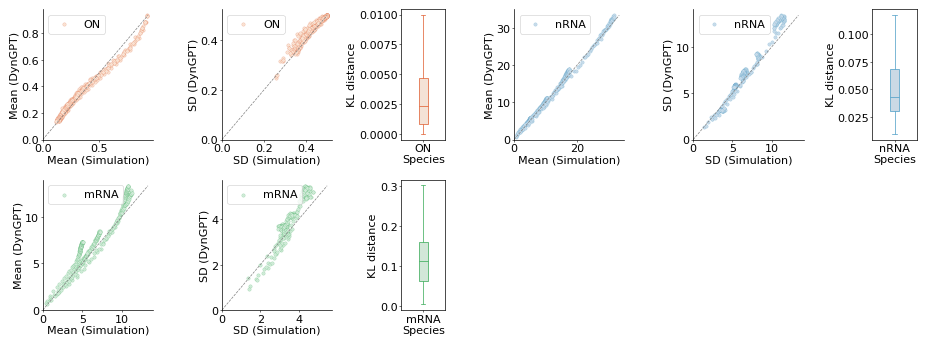

In [20]:
dg.pl.plot_model_comparison_stats(result_valid_set)

### 4. Infer the parameters with DynGPT-Inferrer

In this section, we employ the trained model to infer the corresponding stochastic dynamics from the observed data.

In [7]:
valid_dataset_path =  "data/nm_nm/nm_nm_valid_stable.json"
observed_data,true_params = dg.tl.load_synthetic_data(valid_dataset_path) 

For the inference process, the configuration file is also extended from the basic configuration, defining the following hyperparameters: the trained neural network parameters path (`weight_nn_fine_tune_path`),  the loss function (`inference_loss_func`), the learning rate (`inference_lr`), the maximum number of iterations(`iteration_steps`), the initial number of parameters sampled from the prior distribution (`random_r0_number`), and the threshold for parameter acceptance (`param_acceptance_threshold`).

In [11]:
config_sampling = config_basic
# config_infer.weight_nn_fine_tune_path = result_fine_tune["weight_nn_fine_tune_path"]
config_sampling.weight_nn_fine_tune_path = "/GPUFS/sysu_jjzhang_1/hzw/academicCode/DynGPTTest/DynGPT/dyngpt/_weights/nm_nm_epoch11000.pt"
config_infer.inference_loss_func = "Likelihood"
config_infer.inference_lr = 0.0001
config_infer.iteration_steps = 80
config_infer.random_r0_number = 2
config_infer.param_acceptance_threshold = 0.5 
# result_infer = dg.inferrer.inferring_dynamics(observed_data,config_infer)
result_infer = dg.inferrer.inferring_dynamics(observed_data,config_infer,new_model=True,synthetic_flag=True,test_params = 5)

We visualize the distribution obtained from the observational data with the distribution corresponding to the inferred dynamical parameters.

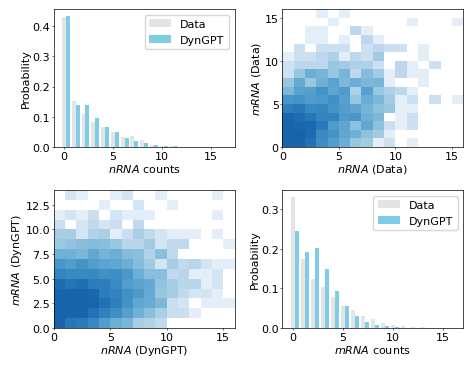

In [16]:
dg.pl.plot_distribution_comparison_nd(result_infer,species_index=[1,2],data_index=[3],width_mm=120)

We visualize the posterior distribution of the inferred dynamical model parameters.

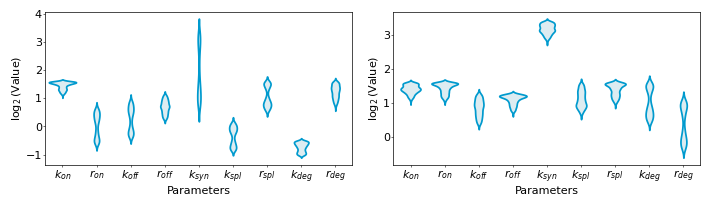

In [18]:
result_infer["param_names"] = np.array(["$k_{on}$", "$r_{on}$", "$k_{off}$", "$r_{off}$", "$k_{syn}$", "$k_{spl}$", "$r_{spl}$", "$k_{deg}$", "$r_{deg}$"])
dg.pl.plot_param_posterior_dist(result_infer,excluded_indexes=[0],true_values=[])